<a href="https://colab.research.google.com/github/tanishka-trivedi/PRML-assignments/blob/main/Assignment02_soln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> PRML Assignment-02</h1>

<p>Name: Tanishka Neeraj Trivedi<p>
Roll no.: B24EE1080

### Part-A:-

<p> Dimensionality Reduction using PCA</p>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<p> 1. Perform exploratory analysis i.e., evaluating data distribution, etc. (use
libraries)</p>

In [ ]:
df = pd.read_csv("heart_cleveland_upload.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [ ]:
df.shape

(297, 14)

In [ ]:
df.info

<bound method DataFrame.info of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     69    1   0       160   234    1        2      131      0      0.1   
1     69    0   0       140   239    0        0      151      0      1.8   
2     66    0   0       150   226    0        0      114      0      2.6   
3     65    1   0       138   282    1        2      174      0      1.4   
4     64    1   0       110   211    0        2      144      1      1.8   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
292   40    1   3       152   223    0        0      181      0      0.0   
293   39    1   3       118   219    0        0      140      0      1.2   
294   35    1   3       120   198    0        0      130      1      1.6   
295   35    0   3       138   183    0        0      182      0      1.4   
296   35    1   3       126   282    0        2      156      1      0.0   

     slope  ca  thal  condition  
0        1   1     0          0  
1        0   2     0          0  
2        2   0     0          0  
3        1   1     0          1  
4        1   0     0          0  
..     ...  ..   ...        ...  
292      0   0     2          1  
293      1   0     2          1  
294      1   0     2          1  
295      0   0     0          0  
296      0   0     2          1  

[297 rows x 14 columns]>

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


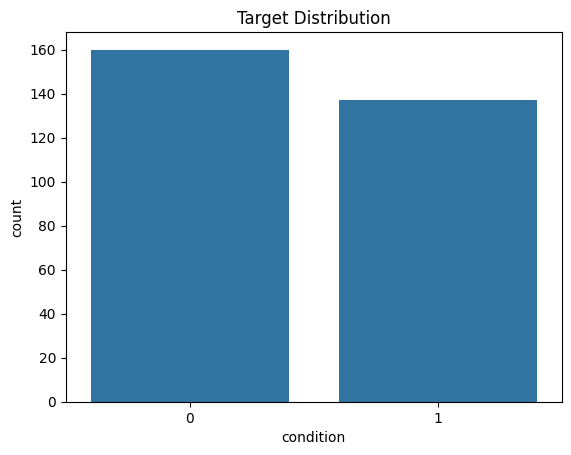

In [ ]:
#Target Distribution

sns.countplot(x='condition', data=df)
plt.title("Target Distribution")
plt.show()

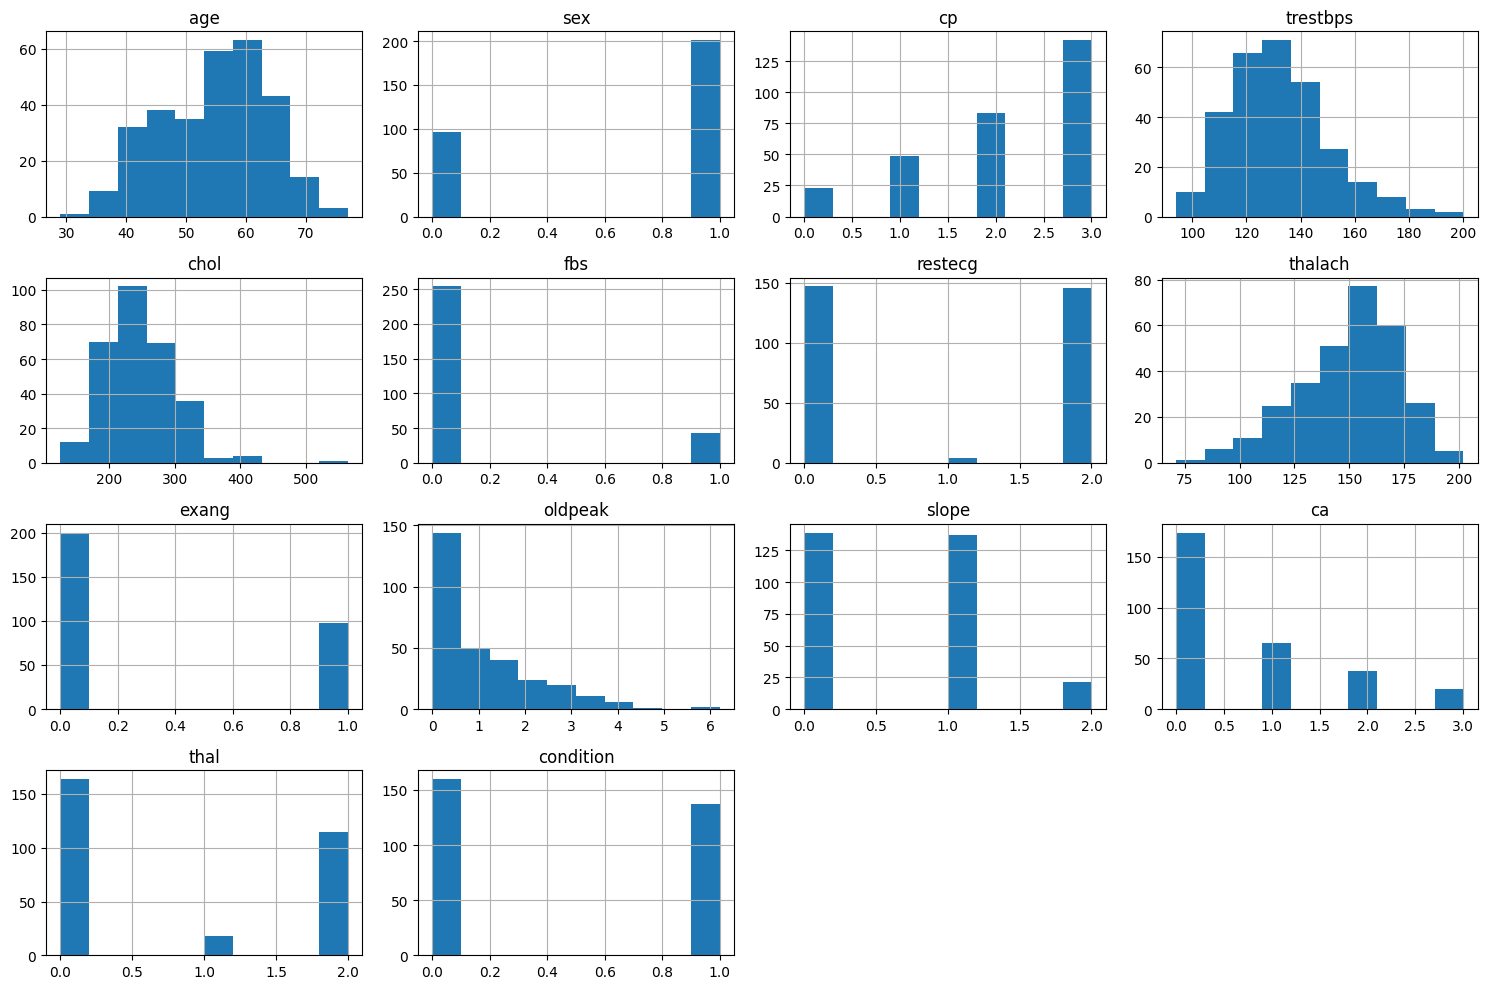

In [ ]:
# Feature Distribution

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

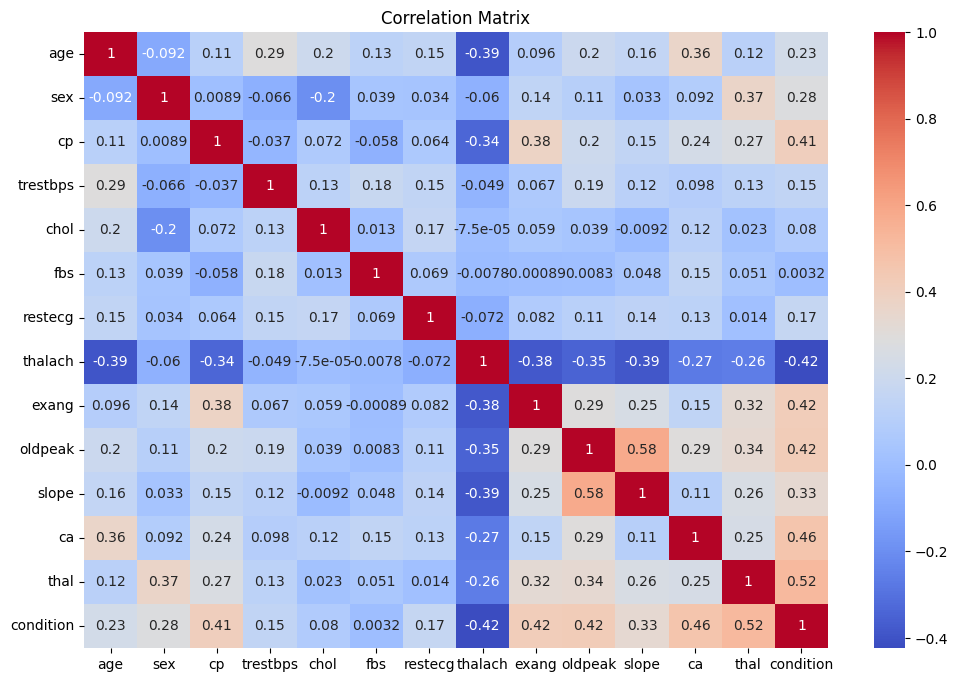

In [ ]:
# Correlation HeatMap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<h5> Note: </h5>
<p> From the above data analysis via EDA, we can see the correlation map and see that some features are highly correlated. Therefore, PCA can help remove redudancy by reducing dimensions. The dataset is moderately balanced.

<p> 2. Implement Principal Component Analysis from scratch without using
any libraries. Visualize the covariance matrix, eigenvalues (sorted) and
explained variance ratio.</p>

In [ ]:
# without using sklearn PCA (from scratch without lib)

X = df.drop("condition", axis=1).values
y = df["condition"].values

# remove target from our features as we do not want y to be in training data being learnt as it would then learn target and overfit

In [ ]:
# Standardize

mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X_std = (X - mean) / std

In [ ]:
n = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n - 1)

print("Covariance Matrix:\n", cov_matrix)

# havifn removed the covariance matrix

Covariance Matrix:
 [[ 1.00337838e+00 -9.27116394e-02  1.10844079e-01  2.91457601e-01
   2.03328152e-01  1.32508144e-01  1.50422987e-01 -3.95895864e-01
   9.68147803e-02  1.97788570e-01  1.59943266e-01  3.63434026e-01
   1.21203134e-01]
 [-9.27116394e-02  1.00337838e+00  8.93812118e-03 -6.65643227e-02
  -1.98758283e-01  3.89815506e-02  3.40113444e-02 -6.07003847e-02
   1.44066322e-01  1.06927268e-01  3.34576164e-02  9.22353569e-02
   3.71807617e-01]
 [ 1.10844079e-01  8.93812118e-03  1.00337838e+00 -3.71046794e-02
   7.23318517e-02 -5.78579173e-02  6.41205889e-02 -3.40453934e-01
   3.78800211e-01  2.03930459e-01  1.51588995e-01  2.36440218e-01
   2.67174977e-01]
 [ 2.91457601e-01 -6.65643227e-02 -3.71046794e-02  1.00337838e+00
   1.31980092e-01  1.81470555e-01  1.49746475e-01 -4.92735683e-02
   6.69163763e-02  1.91889227e-01  1.21581418e-01  9.82846856e-02
   1.31052883e-01]
 [ 2.03328152e-01 -1.98758283e-01  7.23318517e-02  1.31980092e-01
   1.00337838e+00  1.27512142e-02  1.65603623e

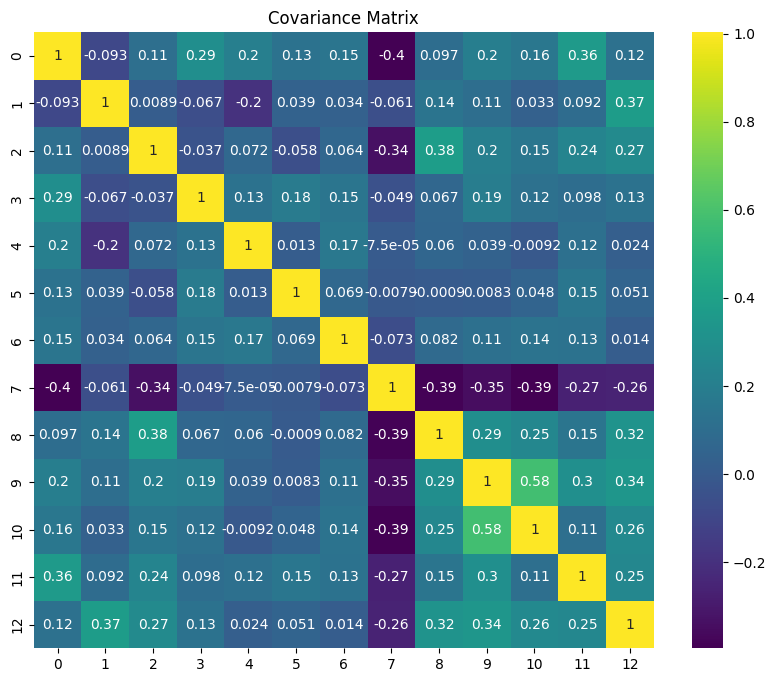

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cov_matrix,annot=True, cmap='viridis')
plt.title("Covariance Matrix")
plt.show()

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvectors
#eigenvectors of cov matrix

array([[ 0.28804678,  0.41733409, -0.01759899,  0.03649823,  0.60347098,
        -0.11833678,  0.01648511, -0.13704684,  0.33470065,  0.25123015,
        -0.32782814, -0.22820735, -0.0964057 ],
       [ 0.11382005, -0.42712301,  0.49426894,  0.12510339,  0.05099038,
        -0.25310115, -0.54227359,  0.02183923, -0.20569429,  0.25098265,
        -0.14664859, -0.20634116, -0.11864049],
       [ 0.28813726, -0.16029577, -0.40486563,  0.0555101 ,  0.14424128,
        -0.32344456, -0.35179282, -0.43038771, -0.02441954, -0.44973595,
         0.03636049,  0.28832148,  0.05060468],
       [ 0.16825492,  0.39467621,  0.3099336 ,  0.10418182, -0.25248138,
         0.17679936, -0.19395838,  0.04335059, -0.10176265, -0.3621411 ,
        -0.44664602,  0.01720103,  0.48292229],
       [ 0.08704643,  0.42132067, -0.26591621,  0.02170911, -0.13302125,
        -0.21032639, -0.22098478, -0.01966883, -0.41155851,  0.41963696,
         0.39519867, -0.18358255,  0.31179479],
       [ 0.07487103,  0.246829

In [ ]:
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

eigenvalues
# sorting the eignvalues in order to remove the largest eignenvalue along which it shows maximum variance.

array([3.07309519, 1.60859584, 1.24558792, 1.11426378, 0.99849013,
       0.88338721, 0.85053701, 0.78243342, 0.6871722 , 0.56963835,
       0.46416524, 0.4094809 , 0.35707174])

In [ ]:
eigenvectors

array([[ 0.28804678,  0.41733409, -0.01759899, -0.11833678,  0.33470065,
        -0.0964057 , -0.22820735, -0.32782814,  0.25123015, -0.13704684,
         0.01648511,  0.60347098,  0.03649823],
       [ 0.11382005, -0.42712301,  0.49426894, -0.25310115, -0.20569429,
        -0.11864049, -0.20634116, -0.14664859,  0.25098265,  0.02183923,
        -0.54227359,  0.05099038,  0.12510339],
       [ 0.28813726, -0.16029577, -0.40486563, -0.32344456, -0.02441954,
         0.05060468,  0.28832148,  0.03636049, -0.44973595, -0.43038771,
        -0.35179282,  0.14424128,  0.0555101 ],
       [ 0.16825492,  0.39467621,  0.3099336 ,  0.17679936, -0.10176265,
         0.48292229,  0.01720103, -0.44664602, -0.3621411 ,  0.04335059,
        -0.19395838, -0.25248138,  0.10418182],
       [ 0.08704643,  0.42132067, -0.26591621, -0.21032639, -0.41155851,
         0.31179479, -0.18358255,  0.39519867,  0.41963696, -0.01966883,
        -0.22098478, -0.13302125,  0.02170911],
       [ 0.07487103,  0.246829

In [ ]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

print("Explained Variance Ratio:\n", explained_variance_ratio)

Explained Variance Ratio:
 [0.23559601 0.12332151 0.09549185 0.085424   0.07654832 0.06772406
 0.06520563 0.05998454 0.05268142 0.0436708  0.0355848  0.03139248
 0.02737458]


<p> Note: Explained Variance ratio is the ratio of each variance to the total variance captured by dataset. That is, it is the proportion of dataset's total variance (information) captured by each principal component. </p>

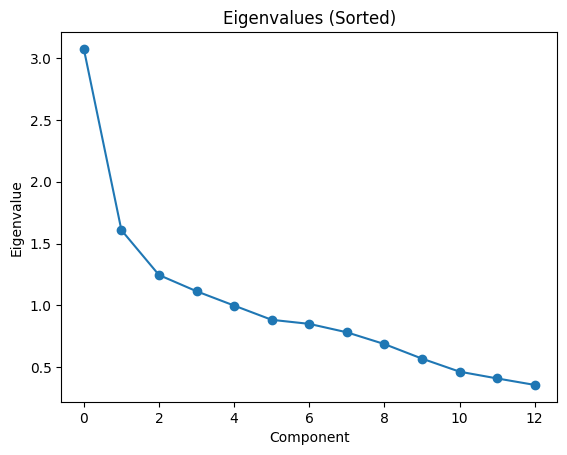

In [ ]:
plt.plot(eigenvalues, marker='o')
plt.title("Eigenvalues (Sorted)")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

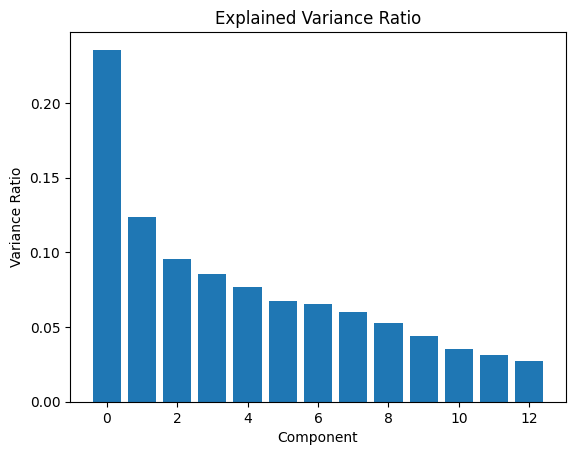

In [ ]:
plt.bar(range(len(explained_variance_ratio)), explained_variance_ratio)
plt.title("Explained Variance Ratio")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

In [ ]:
# Large eigenvalues- more variance captured. Thus, for PCA, we find direction along which maximum variance captured.
# PCA finds new orthogonal axes maximizing variance

<p> 3. Reduce the dataset to 2 principle components and visualize the 2D
scatter plot. (use libraries)</p>

In [ ]:
k = 2
W = eigenvectors[:, :k]

# selecting first 2 PCs

In [ ]:
Z=X_std@W

# Transforming Data

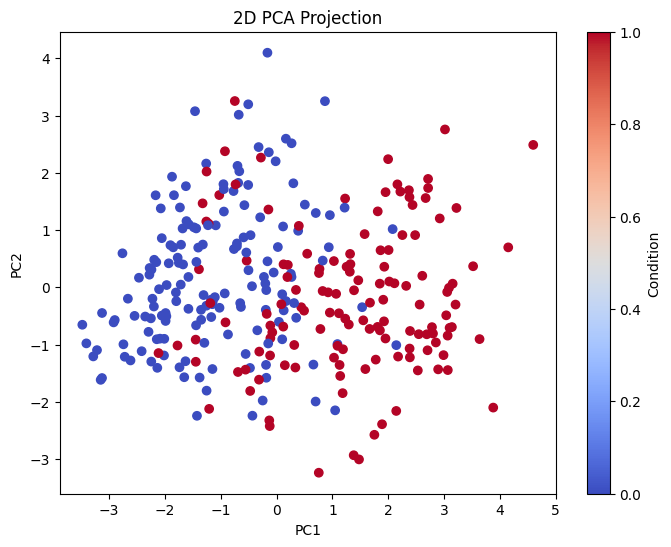

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=y, cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.colorbar(label="Condition")
plt.show()

#PC1 captures maximum variance and PC2 captures second highest variance..

# data is compressed in PCA, while retaining its structure.

Note:
<p> from this plot we can make out that PC1 shows strongest variation as red points are mostly to the right

<p> 4. Reconstruct and Error Analysis: reconstruct data from first 2, 3 and 5
components and compute reconstruction error (Mean Squared Error).</p>

In [ ]:
# Reconstruction- then reverse standardization

def reconstruct_and_mse(k):
    W_k = eigenvectors[:, :k]

    # Projecting data
    Z = X_std @ W_k

    # Reconstruction!
    X_reconstructed_std = Z @ W_k.T

    # then Reverse standardization
    X_reconstructed = X_reconstructed_std * std + mean

    # Computing MSE..
    mse = np.mean((X - X_reconstructed)**2)

    return mse

In [ ]:
for k in [2, 3, 5]:
    mse = reconstruct_and_mse(k)
    print(f"MSE with {k} components:", mse)

MSE with 2 components: 183.75966836868213
MSE with 3 components: 160.29368281140523
MSE with 5 components: 109.23925799694965


<h3>Note:</h3>
<p> MSE decreases as k increases

With all components → MSE ≈ 0->
Shows information loss when reducing dimensions</p>

<p> 5. What happens if the features are not standardized before PCA?</p>

<p> If we don't standardize, features with larger values and larger ranges would dominate and affect the eigenvectors. Since PCA maximizes variance, features with bigger scale would produce larger variance and dominate eigenvectors.</p>

<p> PCA finds directions (principal components) that maximize variance. so for example, lets consider this given dataset itself, Cholesterol varies in hundreds.

Oldpeak varies in single digits

Variance roughly scales with square of magnitude.

So:
Var(Cholesterol)>>Var(Oldpeak)</p>

<p>PCA is sensitive to feature scaling because it maximizes variance. If features are not standardized, variables with larger numerical ranges dominate the covariance matrix, causing principal components to align primarily with high-scale features rather than true data structure. Standardization ensures that each feature contributes equally to the variance computation, leading to meaningful dimensionality reduction.</p>


In [ ]:
# Demonstration for with and without standardization..

# PCA without standardization
cov_no_std = np.cov(X.T)
eigvals_no_std, eigvecs_no_std = np.linalg.eig(cov_no_std)

print("Eigenvalues without scaling:\n", eigvals_no_std)

# PCA with standardization
cov_std = np.cov(X_std.T)
eigvals_std, eigvecs_std = np.linalg.eig(cov_std)

print("Eigenvalues with scaling:\n", eigvals_std)

Eigenvalues without scaling:
 [2.71359974e+03 5.44437900e+02 3.11956307e+02 5.81850618e+01
 1.56842749e+00 9.45465752e-01 8.76346646e-01 6.36283258e-01
 6.53555311e-01 2.14849981e-01 1.13316645e-01 1.68066046e-01
 1.47665925e-01]
Eigenvalues with scaling:
 [3.07309519 1.60859584 1.24558792 0.35707174 0.4094809  1.11426378
 0.46416524 0.56963835 0.99849013 0.6871722  0.78243342 0.85053701
 0.88338721]


<p> This shows how without scaling the eigen values of features show high variance and PCA would then be driven mostly by high-variance features. Thus the scaling ensures all features are given equal importance as we scale them between in a common range.</p>

### Part-B:-

<p> Linear Discriminant Analysis (LDA) for Supervised Projection</p>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

<p> 1. Perform exploratory analysis i.e., names of all features, dataset shape,
class distribution. (use libraries)</p>

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df = pd.read_csv(url, header=None)

df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df["class"] = df["class"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
})

X = df.drop("class", axis=1).values
y = df["class"].values

df.head()


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.shape

(150, 5)

In [ ]:
# feature names
print("Feature Names:", df.columns[:-1].tolist())

Feature Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [ ]:
print(df["class"].value_counts())

class
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
# A balanced dataset!!

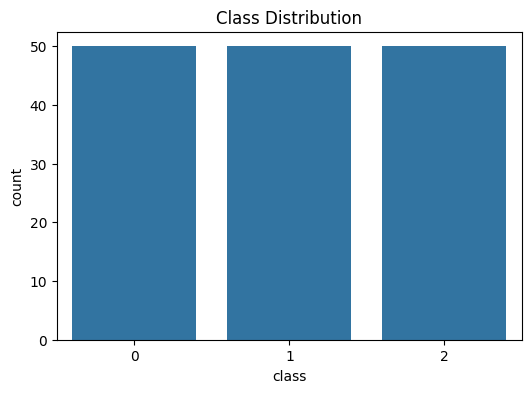

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df)
plt.title("Class Distribution")
plt.show()

# shows no class imbalance..

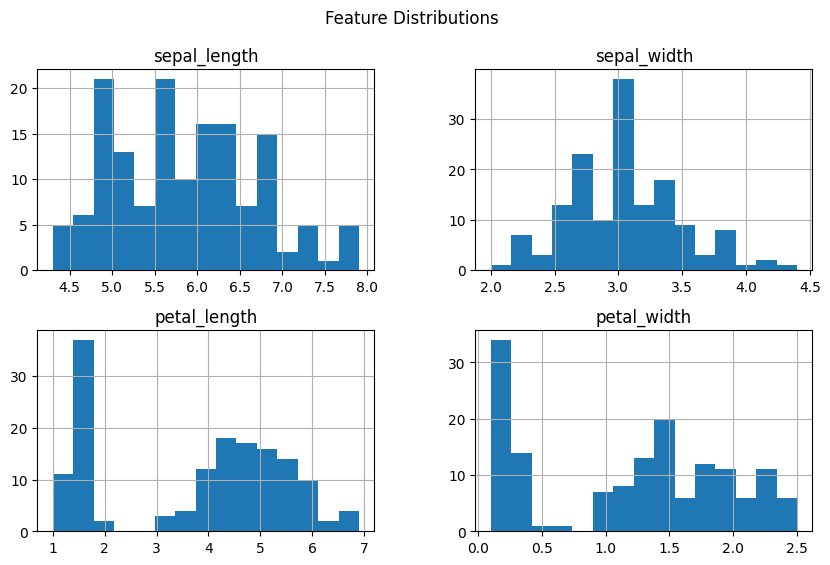

In [ ]:
df.iloc[:, :-1].hist(figsize=(10,6), bins=15)
plt.suptitle("Feature Distributions")
plt.show()

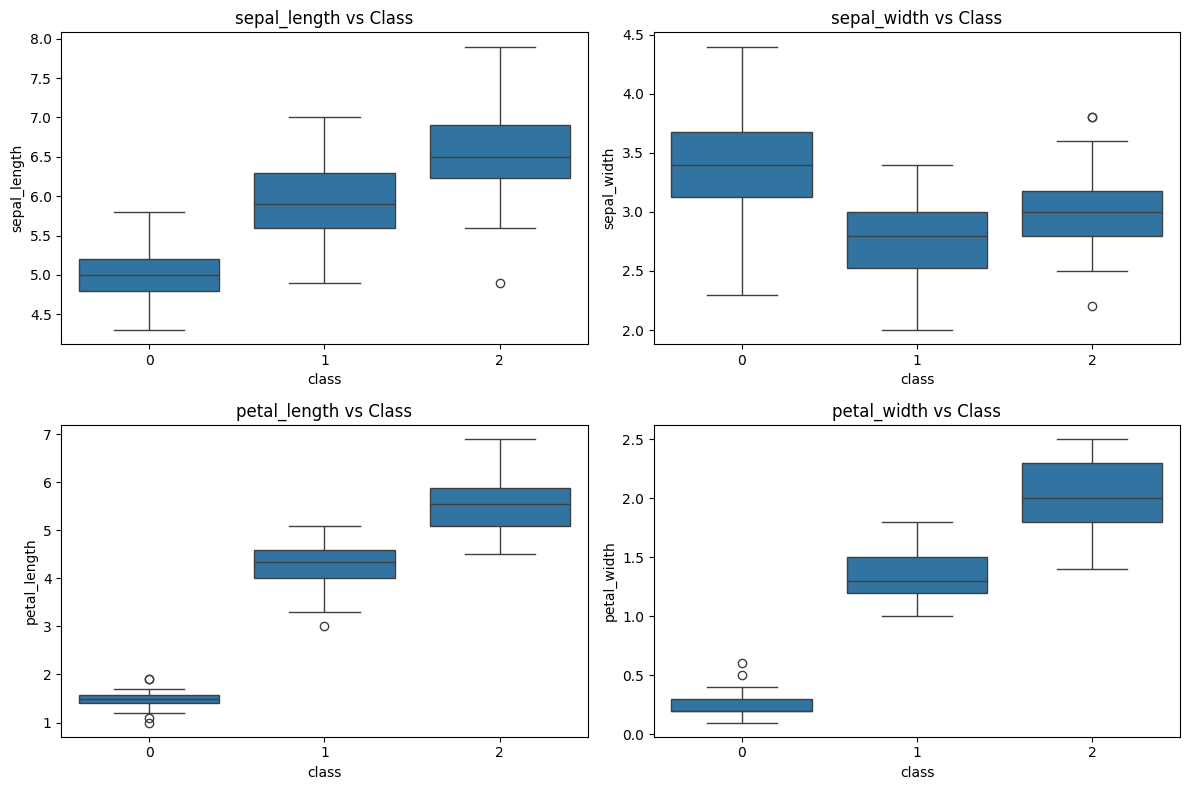

In [ ]:
plt.figure(figsize=(12,8))

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="class", y=col, data=df)
    plt.title(f"{col} vs Class")

plt.tight_layout()
plt.show()

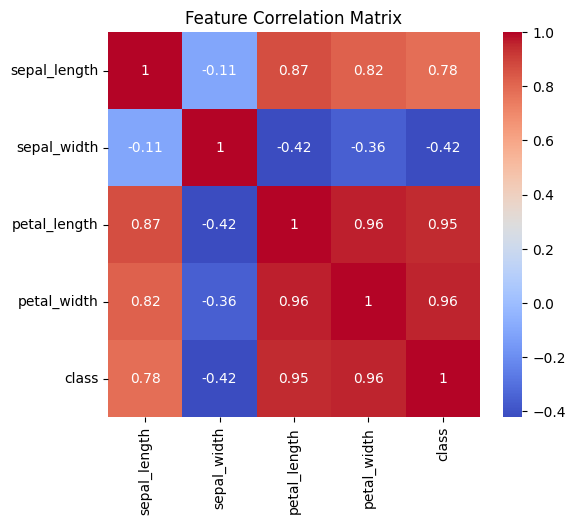

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

<p>From exploratory data analysis, petal length and petal width show strong separation across classes, especially distinguishing Setosa. Sepal features exhibit more overlap. The correlation heatmap reveals strong correlation between petal length and petal width. The dataset is balanced across all three classes, making it suitable for supervised learning using LDA.</p>

<p>2. Implement Linear Discriminant Analysis (from scratch by creating a
function) (The implementation must contain computation of overall
mean, class-wise mean, within-class and between-class scatter
matrices) Visualize the heatmaps of these matrices</p>

<h2>LDA Implementation</h2>

<p>We compute the following steps:</p>

<ol>
    <li>Overall Mean</li>
    <li>Class-wise Mean</li>
    <li>
        Within-class Scatter Matrix
        <strong>S<sub>W</sub></strong>
    </li>
    <li>
        Between-class Scatter Matrix
        <strong>S<sub>B</sub></strong>
    </li>
</ol>

<p>
Solve the eigenvalue equation:
</p>

<p>
(S<sub>W</sub><sup>-1</sup>) S<sub>B</sub> w = λw
</p>

In [ ]:
def lda_from_scratch(X, y):
    n_features = X.shape[1]
    classes = np.unique(y)

    # Overall mean
    mean_overall = np.mean(X, axis=0)

    # Initialize matrices
    S_W = np.zeros((n_features, n_features))
    S_B = np.zeros((n_features, n_features))

    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)

        # Within-class scatter
        S_W += (X_c - mean_c).T @ (X_c - mean_c)

        # Between-class scatter
        n_c = X_c.shape[0]
        mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
        S_B += n_c * (mean_diff @ mean_diff.T)

    # Solve eigenvalue problem
    eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W) @ S_B)

    # Sort eigenvalues
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvals = eigvals[sorted_indices]
    eigvecs = eigvecs[:, sorted_indices]

    return eigvals, eigvecs, S_W, S_B

In [ ]:
#Run LDA
eigvals, eigvecs, S_W, S_B = lda_from_scratch(X, y)

Heat Map Visualization for between classes and within classes:-

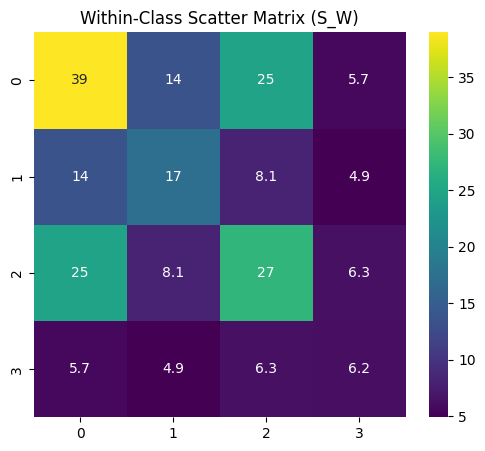

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(S_W, annot=True, cmap="viridis")
plt.title("Within-Class Scatter Matrix (S_W)")
plt.show()

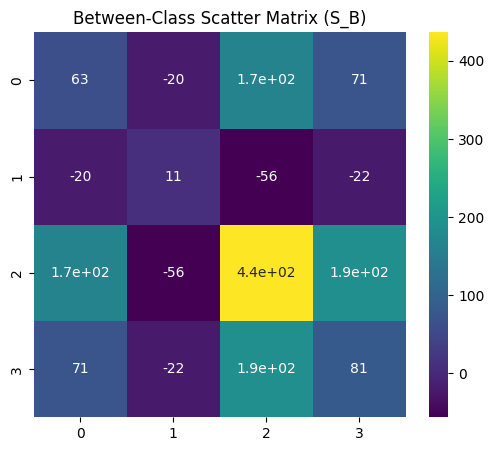

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(S_B, annot=True, cmap="viridis")
plt.title("Between-Class Scatter Matrix (S_B)")
plt.show()

<p> 3. Project dataset onto first 1 and 2 discriminant components. Plot the
scatter diagrams for visualizations.</p>

In [ ]:
# Max LDA components=(c-1) where c= no. of classes

In [ ]:
# Project to 1D
W1 = eigvecs[:, :1]
X_lda_1 = X @ W1



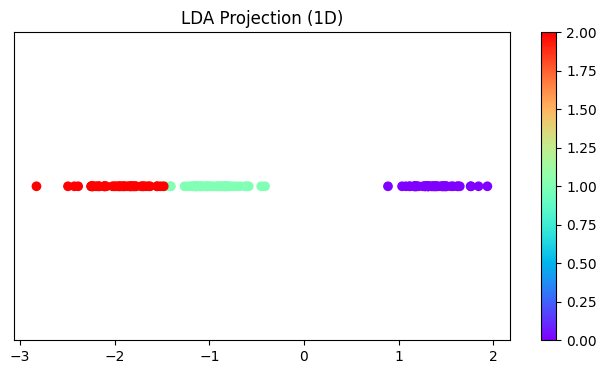

In [ ]:
plt.figure(figsize=(8,4))
scatter=plt.scatter(X_lda_1, np.zeros_like(X_lda_1), c=y, cmap="rainbow")
plt.title("LDA Projection (1D)")
plt.yticks([])
plt.colorbar(scatter)
plt.show()

In [ ]:
# Project to 2D:
W2 = eigvecs[:, :2]
X_lda_2 = X @ W2

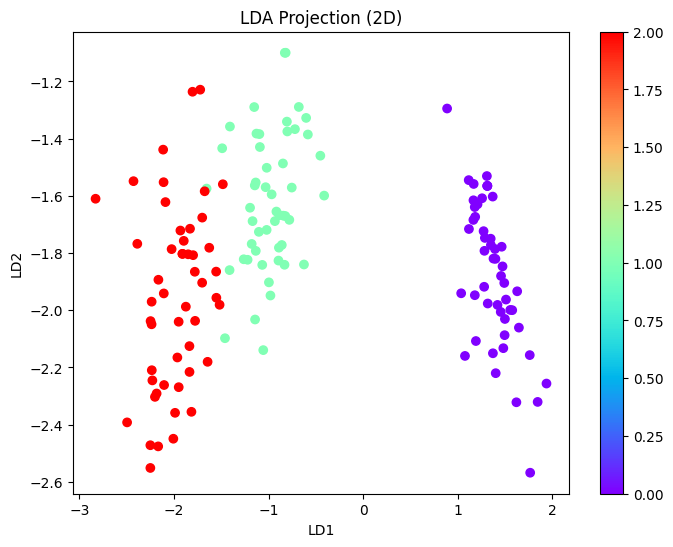

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_lda_2[:,0], X_lda_2[:,1], c=y, cmap="rainbow")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection (2D)")
plt.colorbar()
plt.show()

<p> 4. Use projected features to train a simple classifier (e.g., Logistic
Regression) and report the accuracy. Compare the accuracies before
and after LDA</p>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

In [ ]:
# Logistic Regression before LDA
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc_before = accuracy_score(y_test, y_pred)

print("Accuracy before LDA:", acc_before)

Accuracy before LDA: 1.0


In [ ]:
# Logistics Regression after LDA
X_train_lda = X_train @ W2
X_test_lda = X_test @ W2

In [ ]:
clf2 = LogisticRegression(max_iter=1000)
clf2.fit(X_train_lda, y_train)

y_pred2 = clf2.predict(X_test_lda)
acc_after = accuracy_score(y_test, y_pred2)

print("Accuracy after LDA:", acc_after)

Accuracy after LDA: 0.9833333333333333


<p>Accuracy dropped slightly after LDA since after all, it is a projection. This means that small amount of information is compressed or slightly distorted. After dimensionality reduction using LDA (projecting to 2 components), accuracy slightly decreased to 98.33%, indicating minimal loss of discriminative information. This demonstrates that LDA effectively preserves class-separating structure while reducing dimensionality.</p>

### Conclusion of Assignment:-

<h3>Part A: PCA:-</h3>
<p>PCA reduced the dimensionality of the dataset by identifying orthogonal directions that maximize variance. The explained variance ratio showed that most of the data variability was captured by the first few principal components. Reconstruction error analysis demonstrated that increasing the number of components reduces mean squared error, confirming that PCA effectively compresses data while retaining essential structure. However, PCA does not use class labels, so it focuses purely on variance rather than class separability.</p>

<h3>Part B: LDA:-</h3>
<p>The algorithm computed the overall mean, class-wise means, within-class scatter matrix, and between-class scatter matrix. LDA projected the data onto directions that maximize the ratio of between-class variance to within-class variance. Visualization showed strong separation between classes in the reduced 2D space. When Logistic Regression was trained before and after LDA, accuracy remained very high (1.0 before LDA and 0.9833 after LDA with 40% test split), indicating that LDA preserved almost all discriminative information while reducing dimensionality from 4 to 2.</p>

<p> Thus, we may conclude that Overall, PCA is useful for general dimensionality reduction and noise removal, while LDA is more suitable when class labels are available and class separation is the objective.</p>

<p> Note: PCA is unsupervised while LDA is supervised (PCA ignores output labels.
LDA explicitly uses labels to maximize class separation.)</p>